In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

OUTPUT_PATH = Path("../../data/07_model_output/")
REPORT_PATH = Path("../../data/08_reporting/")

## 1. Cargar resultados de ambos modelos

In [2]:
# Clustering (4,338 clientes - todos)
segmentos = pd.read_parquet(OUTPUT_PATH / "clientes_segmentados.parquet")

# Churn (3,317 clientes - solo periodo de observacion)
churn = pd.read_parquet(OUTPUT_PATH / "churn_predictions.parquet")

# Merge
df = segmentos.merge(
    churn[["CustomerID", "Churn", "churn_prob", "churn_pred"]],
    on="CustomerID",
    how="left",
)

# Clientes sin prediccion de churn = no estaban en periodo de observacion
print(f"Clientes totales (clustering): {len(segmentos):,}")
print(f"Clientes con prediccion de churn: {df['Churn'].notna().sum():,}")
print(f"Clientes sin prediccion (nuevos en periodo de prediccion): {df['Churn'].isna().sum():,}")

# Trabajar solo con clientes que tienen ambos
df_full = df.dropna(subset=["Churn"]).copy()
df_full["Churn"] = df_full["Churn"].astype(int)
df_full["churn_pred"] = df_full["churn_pred"].astype(int)
print(f"\nDataset combinado: {len(df_full):,} clientes")

Clientes totales (clustering): 4,338
Clientes con prediccion de churn: 3,317
Clientes sin prediccion (nuevos en periodo de prediccion): 1,021

Dataset combinado: 3,317 clientes


## 2. Perfil completo de cada segmento

In [3]:
profile = df_full.groupby("Segment_label").agg(
    n_clientes=("CustomerID", "count"),
    # RFM
    recency_mean=("Recency", "mean"),
    frequency_mean=("Frequency", "mean"),
    monetary_mean=("Monetary", "mean"),
    monetary_total=("Monetary", "sum"),
    cancel_rate_mean=("Cancel_rate", "mean"),
    # Producto
    pct_color_mean=("pct_with_color", "mean"),
    color_div_mean=("color_diversity", "mean"),
    pct_material_mean=("pct_with_material", "mean"),
    pct_sets_mean=("pct_purchases_sets", "mean"),
    # Churn
    churn_real=("Churn", "mean"),
    churn_prob_mean=("churn_prob", "mean"),
).round(2)

profile["pct_clientes"] = (profile["n_clientes"] / profile["n_clientes"].sum() * 100).round(1)
profile["pct_revenue"] = (profile["monetary_total"] / profile["monetary_total"].sum() * 100).round(1)
profile["churn_real_pct"] = (profile["churn_real"] * 100).round(1)

print("Perfil completo por segmento:")
display_cols = ["n_clientes", "pct_clientes", "pct_revenue",
                "recency_mean", "frequency_mean", "monetary_mean",
                "cancel_rate_mean", "pct_color_mean", "pct_sets_mean",
                "churn_real_pct", "churn_prob_mean"]
print(profile[display_cols].to_string())

Perfil completo por segmento:
                     n_clientes  pct_clientes  pct_revenue  recency_mean  frequency_mean  monetary_mean  cancel_rate_mean  pct_color_mean  pct_sets_mean  churn_real_pct  churn_prob_mean
Segment_label                                                                                                                                                                            
Compradores de Sets         433          13.1          4.7        133.30            2.49         838.36              1.86           25.96          19.19            56.0             0.49
Dormidos                    946          28.5          6.3        180.52            1.82         514.04              1.74           41.12           4.15            73.0             0.55
En Riesgo                   487          14.7          3.2        177.71            1.84         499.42             16.48           11.46           4.42            71.0             0.61
VIP                        1451         

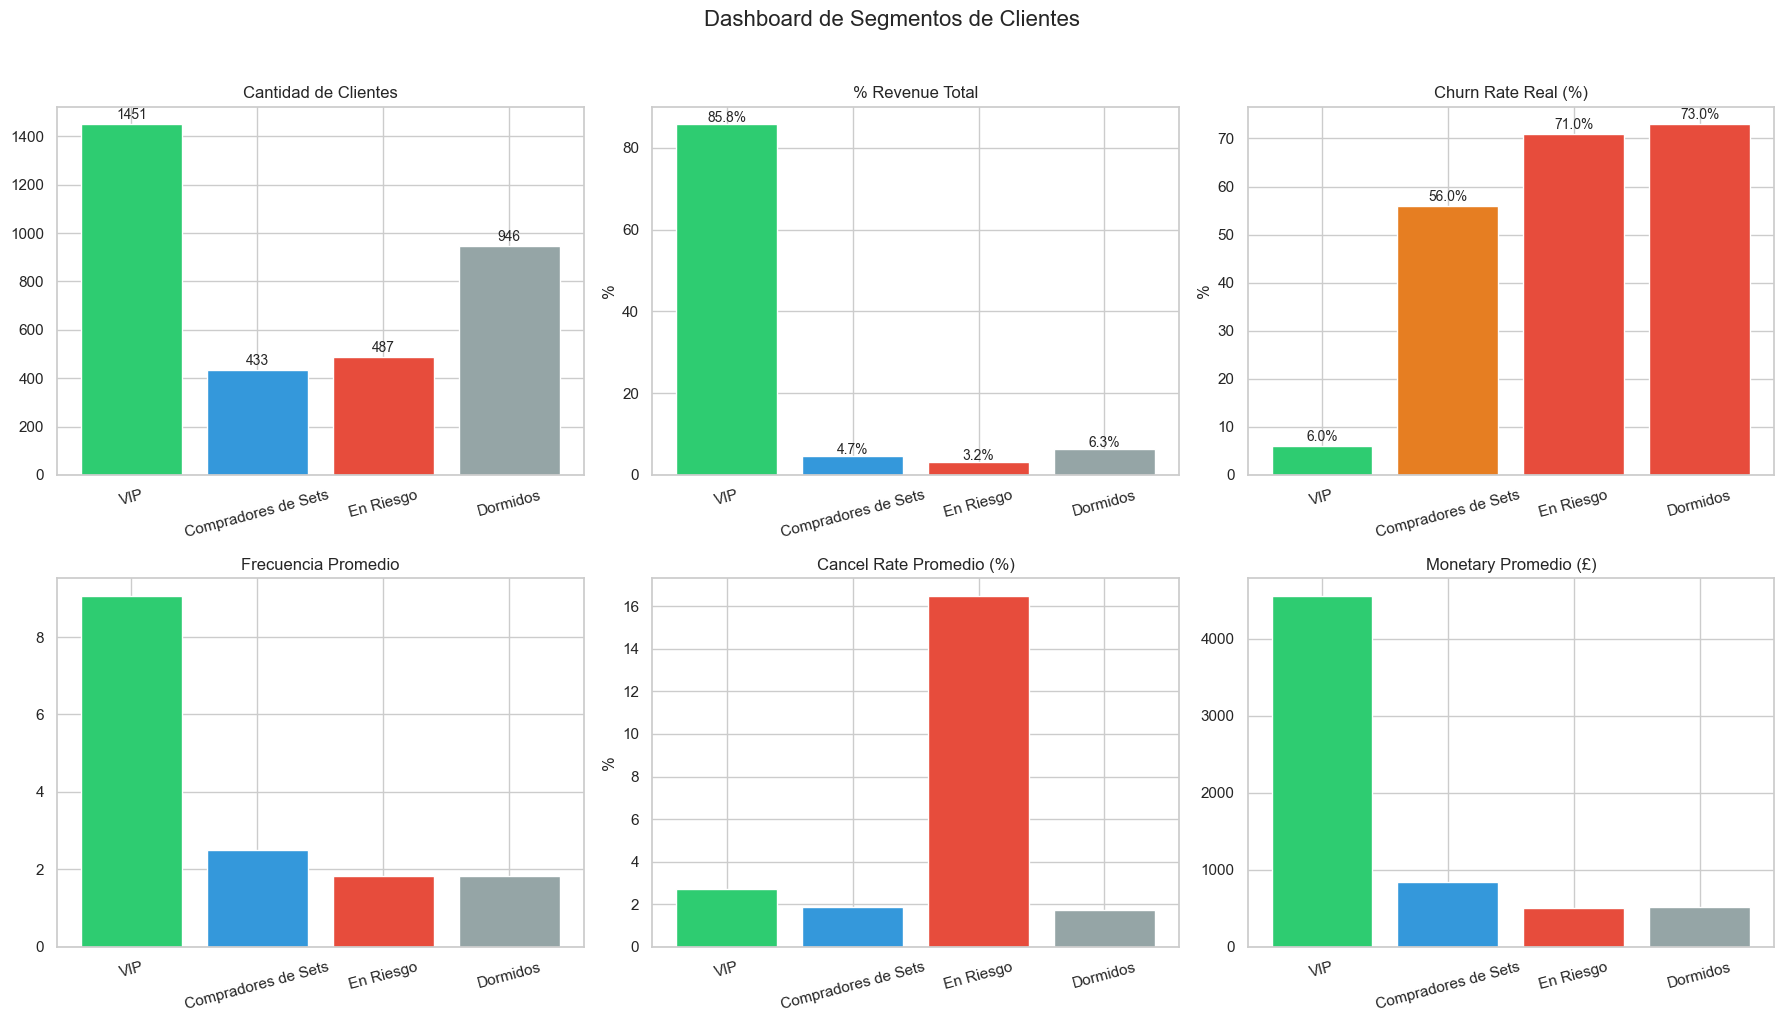

In [4]:
# Visualizacion: dashboard de segmentos
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

segment_order = ["VIP", "Compradores de Sets", "En Riesgo", "Dormidos"]
colors = ["#2ecc71", "#3498db", "#e74c3c", "#95a5a6"]

# 1. Tamanio de segmentos
sizes = profile.loc[segment_order, "n_clientes"]
axes[0, 0].bar(segment_order, sizes, color=colors)
axes[0, 0].set_title("Cantidad de Clientes")
axes[0, 0].tick_params(axis="x", rotation=15)
for i, v in enumerate(sizes):
    axes[0, 0].text(i, v + 20, f"{v}", ha="center", fontsize=10)

# 2. Revenue por segmento
rev = profile.loc[segment_order, "pct_revenue"]
axes[0, 1].bar(segment_order, rev, color=colors)
axes[0, 1].set_title("% Revenue Total")
axes[0, 1].set_ylabel("%")
axes[0, 1].tick_params(axis="x", rotation=15)
for i, v in enumerate(rev):
    axes[0, 1].text(i, v + 0.5, f"{v}%", ha="center", fontsize=10)

# 3. Churn rate real
churn_rates = profile.loc[segment_order, "churn_real_pct"]
bar_colors = ["#2ecc71" if c < 20 else "#e67e22" if c < 60 else "#e74c3c" for c in churn_rates]
axes[0, 2].bar(segment_order, churn_rates, color=bar_colors)
axes[0, 2].set_title("Churn Rate Real (%)")
axes[0, 2].set_ylabel("%")
axes[0, 2].tick_params(axis="x", rotation=15)
for i, v in enumerate(churn_rates):
    axes[0, 2].text(i, v + 1, f"{v}%", ha="center", fontsize=10)

# 4. Frecuencia promedio
freq = profile.loc[segment_order, "frequency_mean"]
axes[1, 0].bar(segment_order, freq, color=colors)
axes[1, 0].set_title("Frecuencia Promedio")
axes[1, 0].tick_params(axis="x", rotation=15)

# 5. Cancel rate promedio
cancel = profile.loc[segment_order, "cancel_rate_mean"]
axes[1, 1].bar(segment_order, cancel, color=colors)
axes[1, 1].set_title("Cancel Rate Promedio (%)")
axes[1, 1].set_ylabel("%")
axes[1, 1].tick_params(axis="x", rotation=15)

# 6. Monetary promedio
mon = profile.loc[segment_order, "monetary_mean"]
axes[1, 2].bar(segment_order, mon, color=colors)
axes[1, 2].set_title("Monetary Promedio (£)")
axes[1, 2].tick_params(axis="x", rotation=15)

plt.suptitle("Dashboard de Segmentos de Clientes", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(REPORT_PATH / "segment_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Matriz de riesgo: Segmento x Churn

Cruzamos el segmento con la prediccion de churn para identificar los grupos
de mayor riesgo de valor (clientes valiosos que estan por irse).

In [5]:
# Tabla de contingencia: segmento x churn real
ct = pd.crosstab(df_full["Segment_label"], df_full["Churn"], margins=True, margins_name="Total")
ct.columns = ["Retained", "Churned", "Total"]
ct["Churn %"] = (ct["Churned"] / ct["Total"] * 100).round(1)

# Revenue en riesgo por segmento
revenue_at_risk = df_full[df_full["Churn"] == 1].groupby("Segment_label")["Monetary"].sum()
ct["Revenue Churned (£)"] = revenue_at_risk.round(0).astype(int)
ct.loc["Total", "Revenue Churned (£)"] = int(revenue_at_risk.sum())

print("Tabla cruzada Segmento x Churn:")
print(ct.to_string())
print(f"\nRevenue total en riesgo de churn: £{revenue_at_risk.sum():,.0f}")

Tabla cruzada Segmento x Churn:
                     Retained  Churned  Total  Churn %  Revenue Churned (£)
Segment_label                                                              
Compradores de Sets       191      242    433     55.9             153680.0
Dormidos                  257      689    946     72.8             324889.0
En Riesgo                 143      344    487     70.6             131267.0
VIP                      1361       90   1451      6.2             185355.0
Total                    1952     1365   3317     41.2             795191.0

Revenue total en riesgo de churn: £795,191


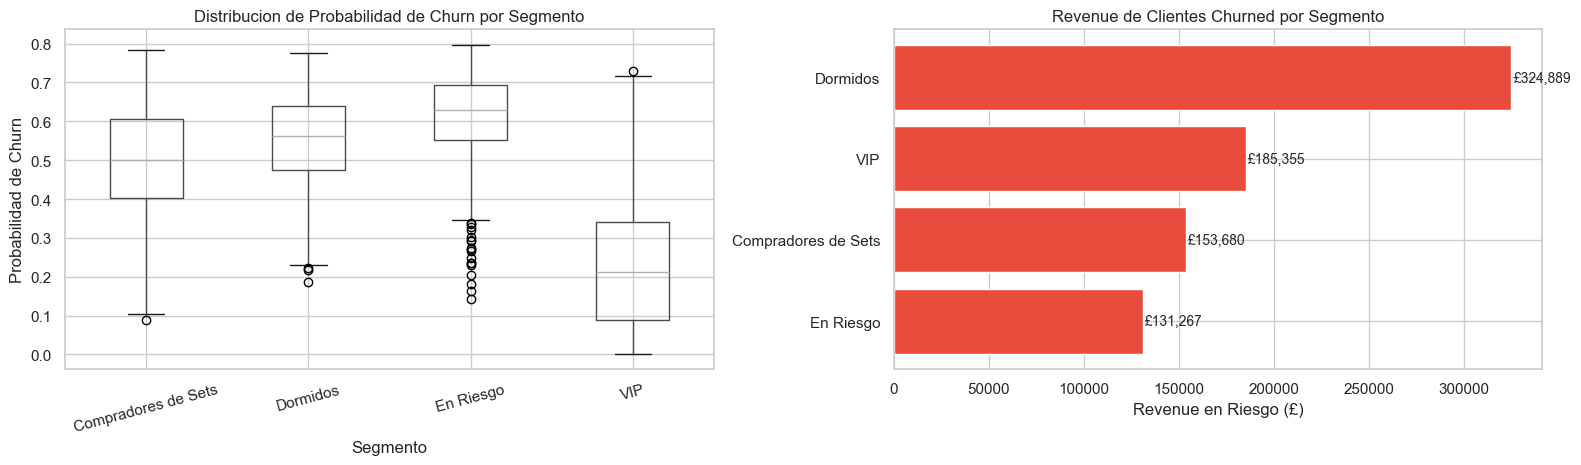

In [6]:
# Matriz visual: segmento x probabilidad de churn
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Boxplot de probabilidad de churn por segmento
df_full.boxplot(column="churn_prob", by="Segment_label", ax=axes[0])
axes[0].set_title("Distribucion de Probabilidad de Churn por Segmento")
axes[0].set_xlabel("Segmento")
axes[0].set_ylabel("Probabilidad de Churn")
axes[0].tick_params(axis="x", rotation=15)
plt.sca(axes[0])
plt.title("Distribucion de Probabilidad de Churn por Segmento")

# Revenue en riesgo por segmento
risk_order = revenue_at_risk.sort_values(ascending=True)
risk_colors = ["#e74c3c" if v > 100000 else "#e67e22" if v > 50000 else "#95a5a6" for v in risk_order]
axes[1].barh(risk_order.index, risk_order.values, color=risk_colors)
axes[1].set_xlabel("Revenue en Riesgo (£)")
axes[1].set_title("Revenue de Clientes Churned por Segmento")
for i, v in enumerate(risk_order.values):
    axes[1].text(v + 1000, i, f"£{v:,.0f}", va="center", fontsize=10)

plt.suptitle("")
plt.tight_layout()
plt.savefig(REPORT_PATH / "segment_churn_risk.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Clientes VIP en riesgo: el grupo de mayor prioridad

Los VIP representan la gran mayoria del revenue. Incluso con un churn rate bajo,
los pocos VIP que se van representan un impacto desproporcionado.

In [7]:
# VIP con alto riesgo de churn (probabilidad > 0.4)
vip_at_risk = df_full[
    (df_full["Segment_label"] == "VIP") & (df_full["churn_prob"] > 0.4)
].sort_values("churn_prob", ascending=False)

print(f"VIP con prob churn > 0.4: {len(vip_at_risk)} clientes")
print(f"Revenue en riesgo: £{vip_at_risk['Monetary'].sum():,.0f}")
print(f"\nPerfil de estos VIP en riesgo:")
print(vip_at_risk[["CustomerID", "Recency", "Frequency", "Monetary",
                    "Cancel_rate", "churn_prob"]].describe().round(1))

# Cuantos realmente hicieron churn?
real_churn = vip_at_risk["Churn"].mean() * 100
print(f"\nDe estos VIP en riesgo, {real_churn:.0f}% realmente hizo churn")

VIP con prob churn > 0.4: 255 clientes
Revenue en riesgo: £449,451

Perfil de estos VIP en riesgo:
       CustomerID  Recency  Frequency  Monetary  Cancel_rate  churn_prob
count       255.0    255.0      255.0     255.0        255.0       255.0
mean      15366.8     31.2        4.0    1762.6          3.8         0.5
std        1640.7     44.2        2.6    3786.4          8.5         0.1
min       12352.0      1.0        2.0     249.7          0.0         0.4
25%       14222.0     10.0        3.0     792.0          0.0         0.4
50%       15485.0     21.0        4.0    1158.3          0.1         0.5
75%       16738.0     33.0        4.0    1816.5          2.9         0.5
max       18287.0    372.0       34.0   57120.9         43.8         0.7

De estos VIP en riesgo, 4% realmente hizo churn


## 5. Recomendaciones de negocio por segmento

In [8]:
# Resumen accionable por segmento
recommendations = pd.DataFrame({
    "Segmento": ["VIP", "Compradores de Sets", "En Riesgo", "Dormidos"],
    "% Clientes": [
        profile.loc["VIP", "pct_clientes"],
        profile.loc["Compradores de Sets", "pct_clientes"],
        profile.loc["En Riesgo", "pct_clientes"],
        profile.loc["Dormidos", "pct_clientes"],
    ],
    "% Revenue": [
        profile.loc["VIP", "pct_revenue"],
        profile.loc["Compradores de Sets", "pct_revenue"],
        profile.loc["En Riesgo", "pct_revenue"],
        profile.loc["Dormidos", "pct_revenue"],
    ],
    "Churn %": [
        profile.loc["VIP", "churn_real_pct"],
        profile.loc["Compradores de Sets", "churn_real_pct"],
        profile.loc["En Riesgo", "churn_real_pct"],
        profile.loc["Dormidos", "churn_real_pct"],
    ],
    "Prioridad": ["ALTA", "MEDIA", "MEDIA", "BAJA"],
    "Estrategia": [
        "Retencion proactiva: programas de fidelidad, atencion preferencial, ofertas exclusivas",
        "Cross-sell: promover productos individuales ademas de sets, cupones personalizados",
        "Recuperacion: investigar causas de cancelacion, resolver problemas de servicio",
        "Reactivacion selectiva: email con descuento, solo si ROI positivo esperado",
    ],
})

print("Recomendaciones de negocio por segmento:\n")
for _, row in recommendations.iterrows():
    print(f"{'='*60}")
    print(f"  {row['Segmento']} ({row['% Clientes']}% clientes, {row['% Revenue']}% revenue)")
    print(f"  Churn: {row['Churn %']}% | Prioridad: {row['Prioridad']}")
    print(f"  Estrategia: {row['Estrategia']}")
print(f"{'='*60}")

Recomendaciones de negocio por segmento:

  VIP (43.7% clientes, 85.8% revenue)
  Churn: 6.0% | Prioridad: ALTA
  Estrategia: Retencion proactiva: programas de fidelidad, atencion preferencial, ofertas exclusivas
  Compradores de Sets (13.1% clientes, 4.7% revenue)
  Churn: 56.0% | Prioridad: MEDIA
  Estrategia: Cross-sell: promover productos individuales ademas de sets, cupones personalizados
  En Riesgo (14.7% clientes, 3.2% revenue)
  Churn: 71.0% | Prioridad: MEDIA
  Estrategia: Recuperacion: investigar causas de cancelacion, resolver problemas de servicio
  Dormidos (28.5% clientes, 6.3% revenue)
  Churn: 73.0% | Prioridad: BAJA
  Estrategia: Reactivacion selectiva: email con descuento, solo si ROI positivo esperado


## 6. Resumen de resultados del proyecto

### Modelo A: Clustering (K-Means)

| Aspecto | Resultado |
|---------|-----------|
| **Algoritmo** | K-Means, k=4, con log-transform + StandardScaler |
| **Features** | 9 (4 RFM + 5 atributos de producto) |
| **Silhouette** | 0.174 (modesto, esperado con features mixtos) |
| **Calinski-Harabasz** | 726.4 |
| **Clusters** | Sin degenerados (rango 14.6% - 36.8%) |

**Segmentos:**
- **VIP (36.8%):** Recientes, frecuentes, alto gasto. 82% del revenue.
- **Dormidos (30.6%):** Alta recency, baja actividad. Candidatos a reactivacion.
- **En Riesgo (18.0%):** Cancel rate 6x mayor. Requieren atencion urgente.
- **Compradores de Sets (14.6%):** Patron de compra por sets/packs. Diferenciados por producto.

### Modelo B: Prediccion de Churn (Random Forest)

| Aspecto | Resultado |
|---------|-----------|
| **Algoritmo** | Random Forest (mejor que Gradient Boosting en CV) |
| **Features** | 13 (4 RFM + 5 producto + 4 adicionales) |
| **F1-score** | 0.62 (clase Churn) |
| **AUC-ROC** | 0.744 |
| **Split temporal** | Obs: dic 2010 - ago 2011 / Pred: sep - dic 2011 |

### Analisis combinado

El cruce de segmentos con churn revela la estructura de riesgo del negocio:
- Los **Dormidos** y **En Riesgo** tienen churn rates de ~70%, pero representan poco revenue
- Los **VIP** tienen churn bajo (~6%), pero cualquier perdida VIP tiene impacto desproporcionado
- Los **Compradores de Sets** tienen churn medio (~56%), indicando que su patron de compra es esporadico

## 7. Reflexion critica (requerida por consigna)

### 7.1 Justificacion del enfoque dual (clustering + churn)

Se eligio combinar un modelo **descriptivo** (clustering K-Means) con uno **predictivo** (clasificacion
de churn) porque responden preguntas de negocio complementarias:

- **Clustering** responde "quienes son nuestros clientes?" - segmenta la base para estrategias diferenciadas
- **Churn** responde "quienes van a dejar de comprar?" - permite accion preventiva antes de perder clientes

Usarlos juntos es mas potente que por separado: saber que un cliente es VIP es util, pero saber
que es un VIP **con alta probabilidad de churn** es accionable. El enfoque dual demuestra dominio
de tecnicas no supervisadas (U4 del curso) y supervisadas, y utiliza los features enriquecidos
en ambos modelos.

### 7.2 Valor del enriquecimiento del campo Description

Tras el feedback de los profesores sobre la limitacion de variables (solo 8 columnas originales),
implementamos extraccion de atributos con regex que genero +50 nuevas columnas por producto.

**En clustering:** Los atributos de producto permitieron descubrir el segmento "Compradores de Sets"
que RFM solo no detecta. La tabla de contingencia RFM-solo vs RFM+producto mostro redistribucion
significativa de clientes.

**En churn:** El impacto fue menor (delta F1 ~ -0.005). Esto tiene sentido: el churn depende
principalmente del comportamiento temporal (Recency domina), no de que productos compro el cliente.
Los atributos de producto aportan mas a *caracterizar* segmentos que a *predecir* abandono.

**Conclusion:** El enriquecimiento fue mas valioso para el modelo descriptivo (clustering) que para
el predictivo (churn). Esto es un hallazgo honesto - no todas las features aportan igual a todos
los modelos.

### 7.3 Limitaciones del dataset

1. **Periodo corto (12 meses):** Solo un ciclo estacional. Imposible validar si los patrones se repiten
   anio a anio. El modelo de churn usa 9 meses para features y 3 para target, lo cual es ajustado.

2. **Sesgo geografico (82% UK):** La segmentacion esta dominada por clientes britanicos. Los patrones
   podrian no ser representativos para mercados internacionales.

3. **Sin datos demograficos:** No hay informacion sobre tipo de negocio, tamanio de empresa, sector.
   Esto limita la interpretabilidad de los segmentos.

4. **CustomerID nulos (24.9%):** Se eliminaron 135K registros. Estos podrian ser clientes ocasionales
   con comportamiento distinto, lo que introduce sesgo de seleccion.

5. **Definicion de churn arbitraria:** "No comprar en 3 meses" es una definicion razonable pero
   arbitraria. Clientes mayoristas pueden tener ciclos de compra mas largos sin ser churn real.

### 7.4 Rendimiento de los modelos: que funciono y que no

**Lo que funciono bien:**
- La segmentacion produce 4 grupos comercialmente interpretables y accionables
- Recency como predictor de churn es muy fuerte y estable
- El split temporal evita data leakage y simula un escenario de produccion real
- Las cancelaciones como feature independiente (Cancel_rate) diferencia claramente el segmento "En Riesgo"

**Lo que no funciono tan bien:**
- Silhouette de clustering es modesto (0.174) - los segmentos se solapan en el espacio de features
- F1 de churn es 0.62 - hay un 38% de clientes churned que el modelo no detecta (falsos negativos)
- Los features de producto no mejoraron la prediccion de churn (Recency domina)
- Gradient Boosting no supero a Random Forest, posiblemente por el tamanio pequenio del dataset (3.3K)

### 7.5 Posibles mejoras

1. **Mas datos temporales:** Con 2+ anios se podria hacer validacion por cohortes y capturar estacionalidad
2. **Features externos:** Datos macroeconomicos, calendario de fiestas, acciones de marketing previas
3. **Otros algoritmos de clustering:** DBSCAN o clustering jerarquico para capturar clusters no esfericos
4. **Threshold tuning en churn:** Optimizar el umbral de decision (no necesariamente 0.5) segun
   el costo de negocio de cada tipo de error (falso positivo vs falso negativo)
5. **Market basket analysis:** Explotar las relaciones entre productos para recomendaciones cruzadas
6. **Datos de interaccion:** Si existieran datos de navegacion web, emails abiertos, soporte, etc.,
   la prediccion de churn mejoraria significativamente

### 7.6 Como los resultados informan decisiones de negocio

El sistema combinado de segmentacion + churn permite a la empresa:

1. **Priorizar inversiones de retencion:** Enfocarse en VIP con alta probabilidad de churn
   (pocos clientes, mucho revenue en juego)
2. **Diferenciar comunicaciones:** No enviar el mismo email a un VIP que a un Dormido
3. **Detectar problemas de servicio:** El segmento "En Riesgo" con cancel rate de 12%
   sugiere un problema sistematico que merece investigacion
4. **Optimizar el ROI de reactivacion:** No gastar en reactivar Dormidos de bajo valor;
   enfocarse en Compradores de Sets que tienen potencial de upgrade

### 7.7 Aprendizajes del proyecto

- El enriquecimiento de datos es una estrategia viable para datasets limitados, pero su impacto
  varia segun el modelo: mas util para descripcion que para prediccion
- La definicion operacional del target (churn) requiere consideracion cuidadosa del contexto de negocio
- El split temporal es fundamental para evitar data leakage en problemas de clasificacion temporal
- Modelos simples con buenas features pueden ser tan efectivos como modelos complejos con features pobres

## Analisis Combinado: Segmentos + Churn

### Por: Grupo 12 - ITBA
### Fecha: 2026-04-16

### Descripcion:
Notebook de interpretacion que cruza los resultados de los dos modelos implementados:

- **Modelo A (Clustering K-Means):** 4 segmentos de clientes basados en RFM + atributos de producto
- **Modelo B (Prediccion de Churn):** Clasificacion binaria con Random Forest

Se generan perfiles accionables por segmento, recomendaciones de negocio diferenciadas,
y una reflexion critica sobre el proyecto completo (requerida por la consigna de Entrega 03).